# Topological Feature Extraction Demo

Bu notebook persistent homology kullanarak time series'lerden topological feature çıkarımını adım adım gösterir.

**Pipeline:**
1. Time Series yükleme ve görselleştirme
2. Takens Embedding (1D → 3D point cloud)
3. Persistent Homology (Ripser)
4. Persistence Diagram çizimi
5. Persistence Landscape hesaplama ve çizimi
6. Feature vector extraction
7. Birden fazla series için batch processing

**Environment:** Python (ts-top)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from ripser import ripser
from topological_features import TopologicalFeatureExtractor

# Plotting settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Imports successful")

✓ Imports successful


## 1. Veri Yükleme

Parquet dosyasından time series verilerini yüklüyoruz.

In [2]:
# Parquet dosyasını yükle
data_path = Path("../data/raw/unified-5k/stationary/ar/long.parquet")

if not data_path.exists():
    print(f"⚠ Dosya bulunamadı: {data_path}")
    print("Lütfen doğru path'i belirtin.")
else:
    df = pd.read_parquet(data_path)
    print(f"✓ Dosya yüklendi: {data_path.name}")
    print(f"\nVeri bilgileri:")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {df.columns.tolist()}")
    print(f"  Toplam series sayısı: {df['series_id'].nunique()}")
    print(f"\nİlk satırlar:")
    display(df.head())

✓ Dosya yüklendi: long.parquet

Veri bilgileri:
  Shape: (3438713, 56)
  Columns: ['series_id', 'time', 'data', 'length', 'is_stationary', 'primary_category', 'sub_category', 'base_series', 'base_process_type', 'order', 'base_coefs', 'trend_type', 'trend_slope', 'trend_intercept', 'trend_coef_a', 'trend_coef_b', 'trend_coef_c', 'trend_damping_rate', 'stochastic_type', 'difference', 'drift_value', 'seasonality_type', 'seasonality_periods', 'seasonality_amplitudes', 'seasonality_from_base', 'seasonal_difference', 'seasonal_ar_order', 'seasonal_ma_order', 'volatility_type', 'volatility_alpha', 'volatility_beta', 'volatility_omega', 'volatility_theta', 'volatility_lambda', 'volatility_gamma', 'volatility_delta', 'anomaly_type', 'anomaly_count', 'anomaly_indices', 'anomaly_magnitudes', 'break_type', 'break_count', 'break_indices', 'break_magnitudes', 'break_directions', 'trend_shift_change_types', 'location_point', 'location_collective', 'location_mean_shift', 'location_variance_shift', 'lo

,series_id,time,data,length,is_stationary,primary_category,sub_category,base_series,base_process_type,order,...,location_point,location_collective,location_mean_shift,location_variance_shift,location_trend_shift,location_contextual,noise_type,noise_std,sampling_frequency,label
0,1,0,0.618411,8270,1,stationary,ar,ar,None,(3),...,None,None,None,None,None,None,None,None,None,ar_long
1,1,1,-1.041652,8270,1,stationary,ar,ar,None,(3),...,None,None,None,None,None,None,None,None,None,ar_long
2,1,2,-0.754603,8270,1,stationary,ar,ar,None,(3),...,None,None,None,None,None,None,None,None,None,ar_long
3,1,3,-0.403297,8270,1,stationary,ar,ar,None,(3),...,None,None,None,None,None,None,None,None,None,ar_long
4,1,4,-0.447987,8270,1,stationary,ar,ar,None,(3),...,None,None,None,None,None,None,None,None,None,ar_long


## 2. Tek Bir Time Series Seçimi ve Görselleştirme

Series ID: 1
Stationary: 1
Category: stationary / ar
Length: 8270
Range: [-4.112, 3.721]


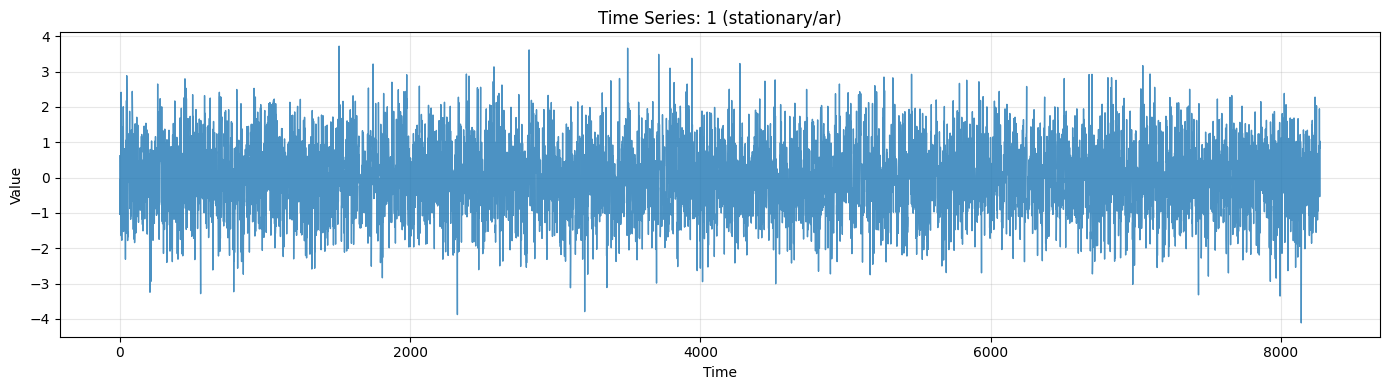


✓ Time series çizildi


In [3]:
# İlk time series'i seç
series_id = df['series_id'].iloc[0]
series_data = df[df['series_id'] == series_id]
time_series = series_data['data'].values

# Metadata
is_stationary = series_data['is_stationary'].iloc[0]
primary_cat = series_data['primary_category'].iloc[0]
sub_cat = series_data['sub_category'].iloc[0]

print(f"Series ID: {series_id}")
print(f"Stationary: {is_stationary}")
print(f"Category: {primary_cat} / {sub_cat}")
print(f"Length: {len(time_series)}")
print(f"Range: [{time_series.min():.3f}, {time_series.max():.3f}]")

# Görselleştir
plt.figure(figsize=(14, 4))
plt.plot(time_series, linewidth=1, alpha=0.8)
plt.title(f"Time Series: {series_id} ({primary_cat}/{sub_cat})")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✓ Time series çizildi")

## 3. Takens Embedding: 1D → 3D Point Cloud

Time series'i 3D point cloud'a dönüştürüyoruz (Takens' theorem).

Point cloud shape: (8268, 3)
Original series: 8270 points (1D)
Embedded cloud: 8268 points (3D)


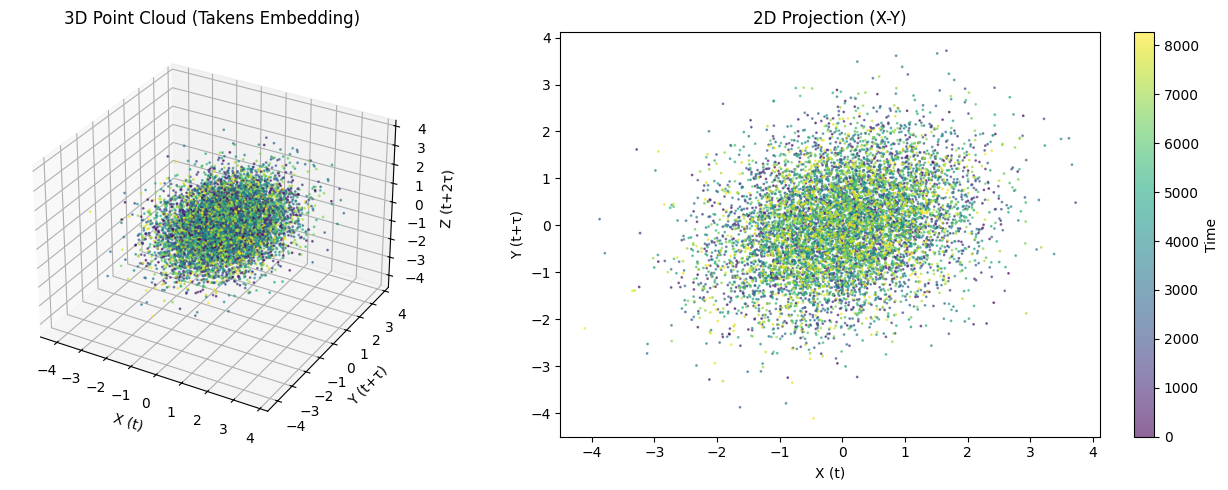


✓ Point cloud görselleştirildi


In [4]:
# Extractor'ı başlat
extractor = TopologicalFeatureExtractor(
    embedding_dim=3,
    embedding_delay=1,
    homology_dims=(0, 1),
    n_landscapes=5,
    landscape_resolution=100,
    normalize=True
)

# Takens embedding
point_cloud = extractor.takens_embedding(time_series)

print(f"Point cloud shape: {point_cloud.shape}")
print(f"Original series: {len(time_series)} points (1D)")
print(f"Embedded cloud: {point_cloud.shape[0]} points (3D)")

# 3D visualization
fig = plt.figure(figsize=(14, 5))

# 3D scatter
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(point_cloud[:, 0], point_cloud[:, 1], point_cloud[:, 2], 
           c=np.arange(len(point_cloud)), cmap='viridis', s=1, alpha=0.6)
ax1.set_xlabel('X (t)')
ax1.set_ylabel('Y (t+τ)')
ax1.set_zlabel('Z (t+2τ)')
ax1.set_title('3D Point Cloud (Takens Embedding)')

# 2D projection (XY)
ax2 = fig.add_subplot(122)
scatter = ax2.scatter(point_cloud[:, 0], point_cloud[:, 1], 
                     c=np.arange(len(point_cloud)), cmap='viridis', s=1, alpha=0.6)
ax2.set_xlabel('X (t)')
ax2.set_ylabel('Y (t+τ)')
ax2.set_title('2D Projection (X-Y)')
plt.colorbar(scatter, ax=ax2, label='Time')

plt.tight_layout()
plt.show()

print("\n✓ Point cloud görselleştirildi")

## 4. Persistent Homology: Ripser

Point cloud'dan persistence diagram'ları hesaplıyoruz.

In [5]:
# Persistence diagrams hesapla
diagrams = extractor.compute_persistence_diagrams(time_series)

print("Persistence Diagrams:")
for dim, diagram in diagrams.items():
    finite_diagram = diagram[np.isfinite(diagram).all(axis=1)]
    print(f"\nH{dim} (Homology dimension {dim}):")
    print(f"  Total pairs: {len(finite_diagram)}")
    if len(finite_diagram) > 0:
        lifetimes = finite_diagram[:, 1] - finite_diagram[:, 0]
        print(f"  Birth range: [{finite_diagram[:, 0].min():.3f}, {finite_diagram[:, 0].max():.3f}]")
        print(f"  Death range: [{finite_diagram[:, 1].min():.3f}, {finite_diagram[:, 1].max():.3f}]")
        print(f"  Lifetime: mean={lifetimes.mean():.3f}, max={lifetimes.max():.3f}")

print("\n✓ Persistence diagrams hesaplandı")

Persistence Diagrams:

H0 (Homology dimension 0):
  Total pairs: 8267
  Birth range: [0.000, 0.000]
  Death range: [0.002, 1.260]
  Lifetime: mean=0.139, max=1.260

H1 (Homology dimension 1):
  Total pairs: 4706
  Birth range: [0.062, 1.201]
  Death range: [0.064, 1.380]
  Lifetime: mean=0.040, max=0.273

✓ Persistence diagrams hesaplandı


## 5. Persistence Diagram Görselleştirme

H0 (connected components) ve H1 (loops) için persistence diagram'ları çiziyoruz.

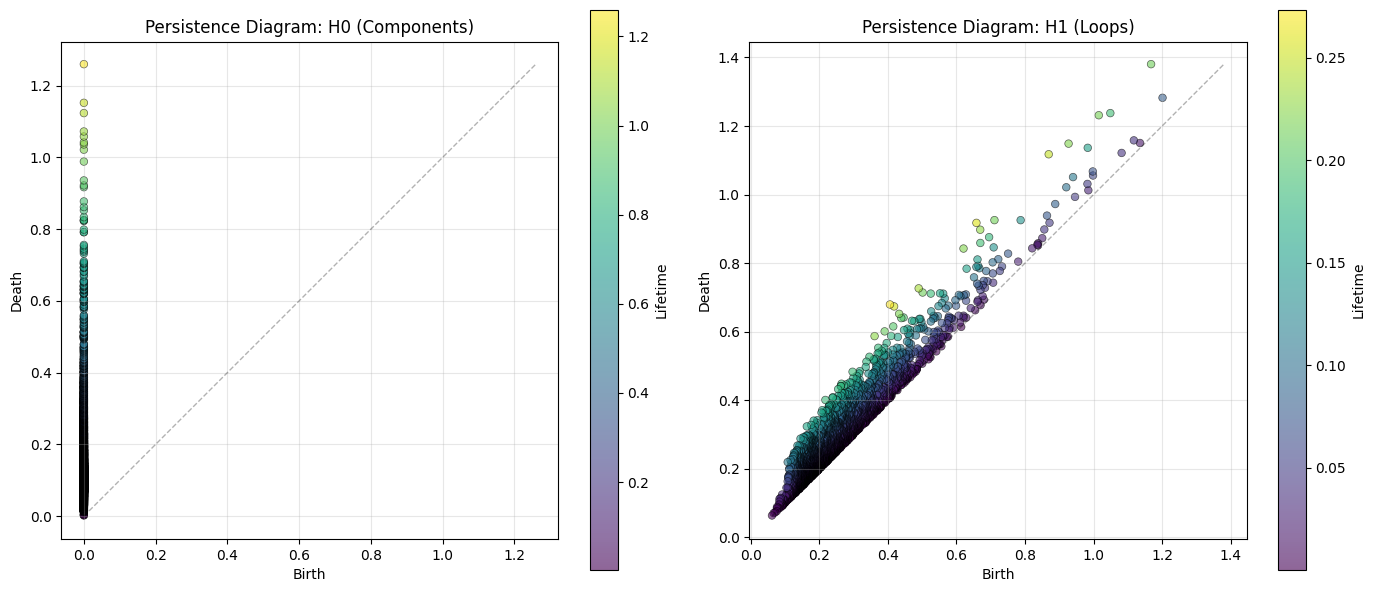

✓ Persistence diagrams çizildi


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = {0: 'blue', 1: 'red'}
labels = {0: 'H0 (Components)', 1: 'H1 (Loops)'}

for idx, (dim, diagram) in enumerate(diagrams.items()):
    ax = axes[idx]
    
    # Finite points only
    finite_diagram = diagram[np.isfinite(diagram).all(axis=1)]
    
    if len(finite_diagram) > 0:
        # Scatter plot
        births = finite_diagram[:, 0]
        deaths = finite_diagram[:, 1]
        lifetimes = deaths - births
        
        scatter = ax.scatter(births, deaths, c=lifetimes, cmap='viridis', 
                           s=30, alpha=0.6, edgecolors='black', linewidth=0.5)
        
        # Diagonal line (birth = death)
        max_val = max(deaths.max(), births.max())
        min_val = min(deaths.min(), births.min())
        ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.3, linewidth=1)
        
        ax.set_xlabel('Birth')
        ax.set_ylabel('Death')
        ax.set_title(f'Persistence Diagram: {labels[dim]}')
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
        
        plt.colorbar(scatter, ax=ax, label='Lifetime')
    else:
        ax.text(0.5, 0.5, 'No finite persistence pairs', 
               ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Persistence Diagram: {labels[dim]}')

plt.tight_layout()
plt.show()

print("✓ Persistence diagrams çizildi")

## 6. Persistence Landscape Hesaplama

Persistence diagram'larını sabit boyutlu feature vector'lere dönüştürüyoruz.

In [7]:
# Her homology dimension için landscape hesapla
landscape_data = {}

for dim, diagram in diagrams.items():
    landscape_vector = extractor.compute_persistence_landscape(diagram)
    
    # Reshape to (n_landscapes, resolution)
    landscape_matrix = landscape_vector.reshape(extractor.n_landscapes, extractor.landscape_resolution)
    landscape_data[dim] = landscape_matrix
    
    print(f"H{dim} Landscape:")
    print(f"  Vector shape: {landscape_vector.shape}")
    print(f"  Matrix shape: {landscape_matrix.shape} ({extractor.n_landscapes} landscapes x {extractor.landscape_resolution} bins)")
    print(f"  Range: [{landscape_vector.min():.3f}, {landscape_vector.max():.3f}]")
    print(f"  Non-zero: {np.count_nonzero(landscape_vector)}/{len(landscape_vector)}")
    print()

print("✓ Landscapes hesaplandı")

H0 Landscape:
  Vector shape: (500,)
  Matrix shape: (5, 100) (5 landscapes x 100 bins)
  Range: [0.000, 0.623]
  Non-zero: 443/500

H1 Landscape:
  Vector shape: (500,)
  Matrix shape: (5, 100) (5 landscapes x 100 bins)
  Range: [0.000, 0.135]
  Non-zero: 435/500

✓ Landscapes hesaplandı


## 7. Persistence Landscape Görselleştirme

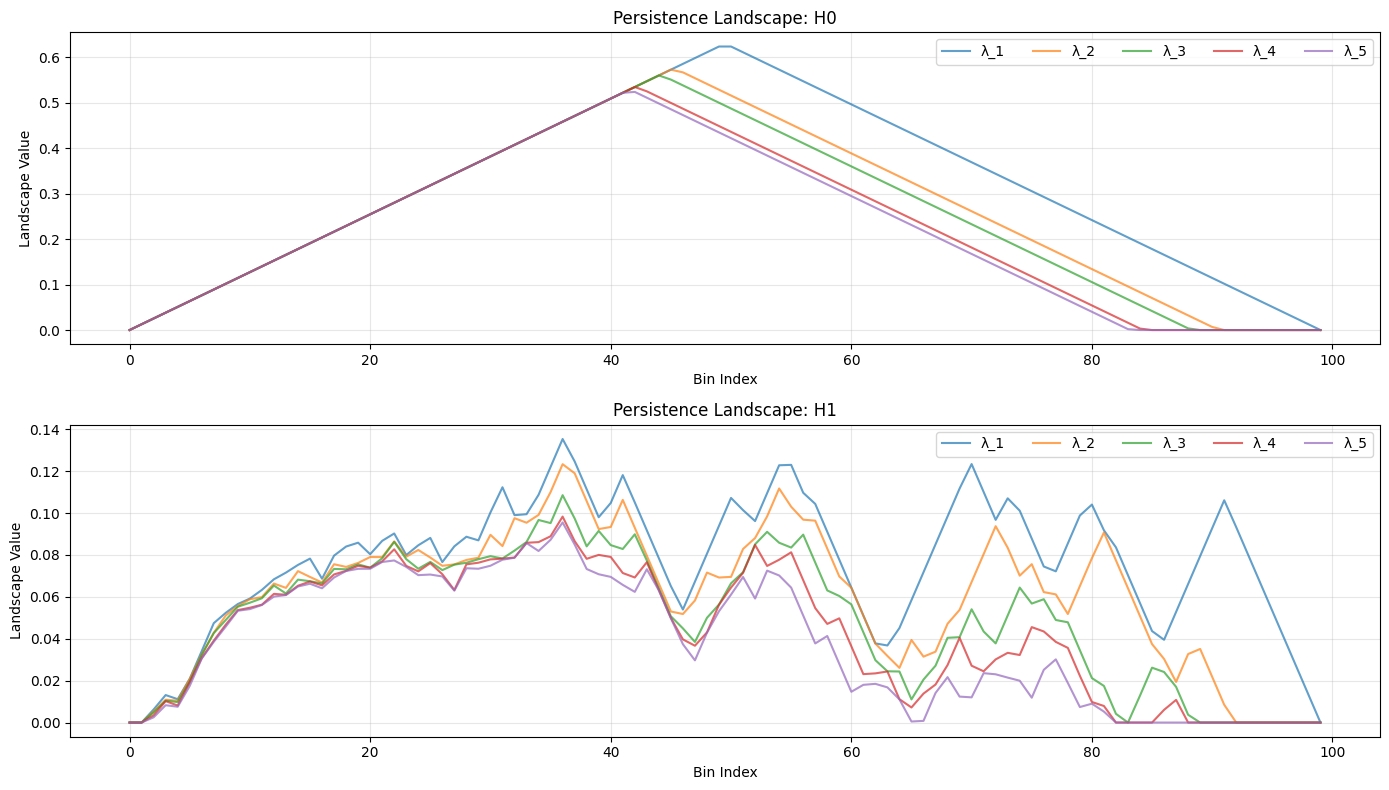

✓ Landscapes çizildi


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for idx, (dim, landscape_matrix) in enumerate(landscape_data.items()):
    ax = axes[idx]
    
    # Plot each landscape function
    x = np.arange(extractor.landscape_resolution)
    
    for k in range(extractor.n_landscapes):
        ax.plot(x, landscape_matrix[k, :], label=f'λ_{k+1}', alpha=0.7, linewidth=1.5)
    
    ax.set_xlabel('Bin Index')
    ax.set_ylabel('Landscape Value')
    ax.set_title(f'Persistence Landscape: H{dim}')
    ax.legend(loc='upper right', ncol=5)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Landscapes çizildi")

## 8. Final Feature Vector

Tüm landscape'leri birleştirerek tek bir feature vector oluşturuyoruz.

Final Feature Vector:
  Shape: (1000,)
  Total features: 1000
  Range: [0.000, 1.000]
  Non-zero: 878 / 1000

First 10 features:
  topo_H0_L0_bin0                = 0.0000
  topo_H0_L0_bin1                = 0.0204
  topo_H0_L0_bin2                = 0.0408
  topo_H0_L0_bin3                = 0.0612
  topo_H0_L0_bin4                = 0.0816
  topo_H0_L0_bin5                = 0.1020
  topo_H0_L0_bin6                = 0.1224
  topo_H0_L0_bin7                = 0.1429
  topo_H0_L0_bin8                = 0.1633
  topo_H0_L0_bin9                = 0.1837


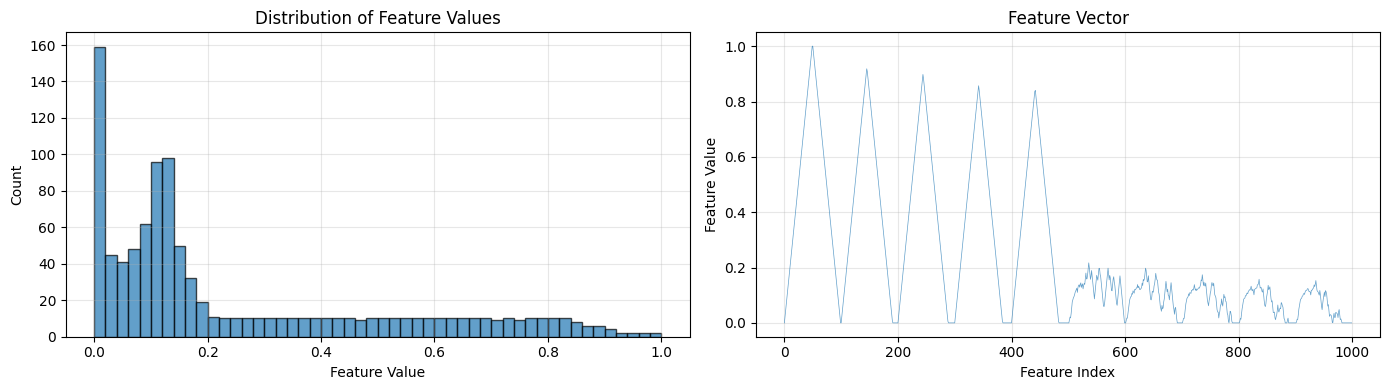


✓ Feature vector oluşturuldu


In [9]:
# End-to-end feature extraction
feature_vector = extractor.extract_features(time_series)
feature_names = extractor.get_feature_names()

print(f"Final Feature Vector:")
print(f"  Shape: {feature_vector.shape}")
print(f"  Total features: {len(feature_vector)}")
print(f"  Range: [{feature_vector.min():.3f}, {feature_vector.max():.3f}]")
print(f"  Non-zero: {np.count_nonzero(feature_vector)} / {len(feature_vector)}")
print(f"\nFirst 10 features:")
for i in range(10):
    print(f"  {feature_names[i]:30s} = {feature_vector[i]:.4f}")

# Histogram
plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
plt.hist(feature_vector, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Feature Value')
plt.ylabel('Count')
plt.title('Distribution of Feature Values')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(feature_vector, linewidth=0.5, alpha=0.7)
plt.xlabel('Feature Index')
plt.ylabel('Feature Value')
plt.title('Feature Vector')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Feature vector oluşturuldu")

## 9. Birden Fazla Series için Batch Processing

Şimdi 2 farklı time series için topological features çıkarıp karşılaştıracağız.

In [10]:
# İlk 2 farklı series'i seç
unique_ids = df['series_id'].unique()[:2]
print(f"Seçilen series: {unique_ids}")

# Series'leri hazırla
series_dict = {}
series_metadata = {}

for sid in unique_ids:
    series_data = df[df['series_id'] == sid]
    series_dict[sid] = series_data['data'].values
    
    # Metadata
    series_metadata[sid] = {
        'is_stationary': series_data['is_stationary'].iloc[0],
        'primary_category': series_data['primary_category'].iloc[0],
        'sub_category': series_data['sub_category'].iloc[0]
    }

print(f"\nSeries bilgileri:")
for sid, meta in series_metadata.items():
    print(f"  {sid}: {meta['primary_category']}/{meta['sub_category']} (stationary={meta['is_stationary']})")

Seçilen series: [1 2]

Series bilgileri:
  1: stationary/ar (stationary=1)
  2: stationary/ar (stationary=1)


### 9.1 İki Series'i Görselleştir

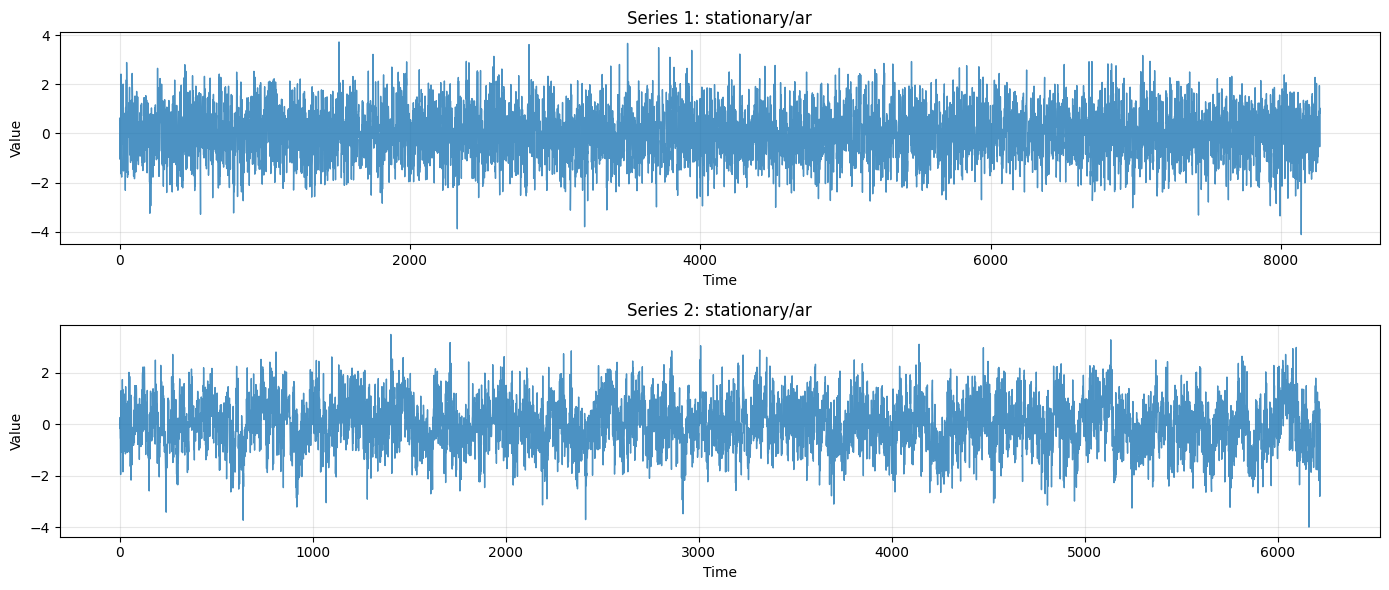

✓ Time series'ler çizildi


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

for idx, (sid, ts) in enumerate(series_dict.items()):
    ax = axes[idx]
    meta = series_metadata[sid]
    
    ax.plot(ts, linewidth=1, alpha=0.8)
    ax.set_title(f"Series {sid}: {meta['primary_category']}/{meta['sub_category']}")
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Time series'ler çizildi")

### 9.2 Batch Feature Extraction

In [12]:
# Batch extraction (n_jobs=1 for notebook)
features_df, failed = extractor.extract_batch(series_dict, n_jobs=2, verbose=True)

print(f"\nExtraction sonuçları:")
print(f"  Başarılı: {len(features_df)} series")
print(f"  Başarısız: {len(failed)} series")
print(f"  Feature sayısı: {features_df.shape[1] - 1}")

print(f"\nFeatures DataFrame:")
display(features_df)

  Processing 2 series with 2 jobs...


  Extracting features: 100%|██████████| 2/2 [00:00<00:00, 73.34it/s]



Extraction sonuçları:
  Başarılı: 2 series
  Başarısız: 0 series
  Feature sayısı: 1000

Features DataFrame:


,topo_H0_L0_bin0,topo_H0_L0_bin1,topo_H0_L0_bin2,topo_H0_L0_bin3,topo_H0_L0_bin4,topo_H0_L0_bin5,topo_H0_L0_bin6,topo_H0_L0_bin7,topo_H0_L0_bin8,topo_H0_L0_bin9,...,topo_H1_L4_bin91,topo_H1_L4_bin92,topo_H1_L4_bin93,topo_H1_L4_bin94,topo_H1_L4_bin95,topo_H1_L4_bin96,topo_H1_L4_bin97,topo_H1_L4_bin98,topo_H1_L4_bin99,series_id
0,0.0,0.020408,0.040816,0.061224,0.081633,0.102041,0.122449,0.142857,0.163265,0.183673,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.0,0.020408,0.040816,0.061224,0.081633,0.102041,0.122449,0.142857,0.163265,0.183673,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2


## 10. Final DataFrame: Features + Metadata + Labels

In [13]:
# Metadata DataFrame
metadata_df = pd.DataFrame.from_dict(series_metadata, orient='index')
metadata_df.index.name = 'series_id'
metadata_df = metadata_df.reset_index()

print("Metadata:")
display(metadata_df)

# Merge
final_df = features_df.merge(metadata_df, on='series_id', how='left')

# Reorder columns
metadata_cols = ['series_id', 'is_stationary', 'primary_category', 'sub_category']
feature_cols = [col for col in final_df.columns if col.startswith('topo_')]
final_df = final_df[metadata_cols + feature_cols]

print(f"\n{'='*80}")
print(f"FINAL DATAFRAME")
print(f"{'='*80}")
print(f"Shape: {final_df.shape}")
print(f"Columns: {len(metadata_cols)} metadata + {len(feature_cols)} features")
print(f"\nData:")
display(final_df)

print(f"\nFeature statistics:")
display(final_df[feature_cols].describe())

Metadata:


,series_id,is_stationary,primary_category,sub_category
0,1,1,stationary,ar
1,2,1,stationary,ar



FINAL DATAFRAME
Shape: (2, 1004)
Columns: 4 metadata + 1000 features

Data:


,series_id,is_stationary,primary_category,sub_category,topo_H0_L0_bin0,topo_H0_L0_bin1,topo_H0_L0_bin2,topo_H0_L0_bin3,topo_H0_L0_bin4,topo_H0_L0_bin5,...,topo_H1_L4_bin90,topo_H1_L4_bin91,topo_H1_L4_bin92,topo_H1_L4_bin93,topo_H1_L4_bin94,topo_H1_L4_bin95,topo_H1_L4_bin96,topo_H1_L4_bin97,topo_H1_L4_bin98,topo_H1_L4_bin99
0,1,1,stationary,ar,0.0,0.020408,0.040816,0.061224,0.081633,0.102041,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,1,stationary,ar,0.0,0.020408,0.040816,0.061224,0.081633,0.102041,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Feature statistics:


,topo_H0_L0_bin0,topo_H0_L0_bin1,topo_H0_L0_bin2,topo_H0_L0_bin3,topo_H0_L0_bin4,topo_H0_L0_bin5,topo_H0_L0_bin6,topo_H0_L0_bin7,topo_H0_L0_bin8,topo_H0_L0_bin9,...,topo_H1_L4_bin90,topo_H1_L4_bin91,topo_H1_L4_bin92,topo_H1_L4_bin93,topo_H1_L4_bin94,topo_H1_L4_bin95,topo_H1_L4_bin96,topo_H1_L4_bin97,topo_H1_L4_bin98,topo_H1_L4_bin99
count,2.0,2.000000,2.000000,2.000000e+00,2.000000,2.000000e+00,2.000000e+00,2.000000,2.000000,2.000000,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
mean,0.0,0.020408,0.040816,6.122449e-02,0.081633,1.020408e-01,1.224490e-01,0.142857,0.163265,0.183673,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,0.0,0.000000,0.000000,6.938894e-18,0.000000,1.387779e-17,1.387779e-17,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.0,0.020408,0.040816,6.122449e-02,0.081633,1.020408e-01,1.224490e-01,0.142857,0.163265,0.183673,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.020408,0.040816,6.122449e-02,0.081633,1.020408e-01,1.224490e-01,0.142857,0.163265,0.183673,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.020408,0.040816,6.122449e-02,0.081633,1.020408e-01,1.224490e-01,0.142857,0.163265,0.183673,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.020408,0.040816,6.122449e-02,0.081633,1.020408e-01,1.224490e-01,0.142857,0.163265,0.183673,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,0.0,0.020408,0.040816,6.122449e-02,0.081633,1.020408e-01,1.224490e-01,0.142857,0.163265,0.183673,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 11. Feature Comparison

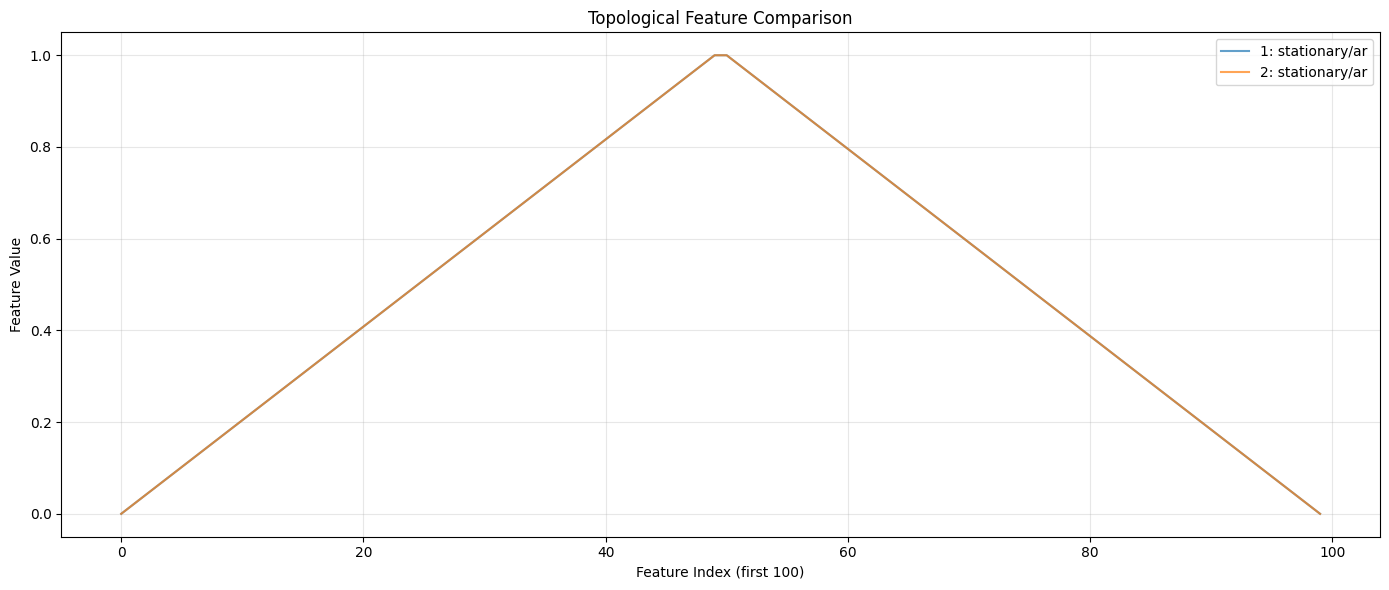

✓ Karşılaştırma tamamlandı


: 

In [ ]:
# İlk 100 feature karşılaştır
n_plot = 100
feature_subset = feature_cols[:n_plot]

plt.figure(figsize=(14, 6))

for idx, row in final_df.iterrows():
    sid = row['series_id']
    label = f"{sid}: {row['primary_category']}/{row['sub_category']}"
    plt.plot(row[feature_subset].values, label=label, alpha=0.7, linewidth=1.5)

plt.xlabel(f'Feature Index (first {n_plot})')
plt.ylabel('Feature Value')
plt.title('Topological Feature Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Karşılaştırma tamamlandı")

---

## Summary

✅ Tamamlanan adımlar:
1. Parquet → Time series yükleme
2. Time series görselleştirme
3. Takens embedding (1D → 3D)
4. Persistent homology (Ripser)
5. Persistence diagram çizimi
6. Persistence landscape hesaplama ve çizimi
7. Feature vector extraction
8. Birden fazla series için batch processing
9. **Final DataFrame: series_id + metadata + topological features**

Gerçek kullanım:
```bash
python topological_features.py --input ../data/raw/unified-5k \
                               --output ../data/features/unified-5k/topological \
                               --n-jobs 16 --chunk-size 10
```